**Part 1- Neural Network**

In [1]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
import matplotlib.pyplot as plt

import cv2
from pathlib import Path
import keras
from keras import layers

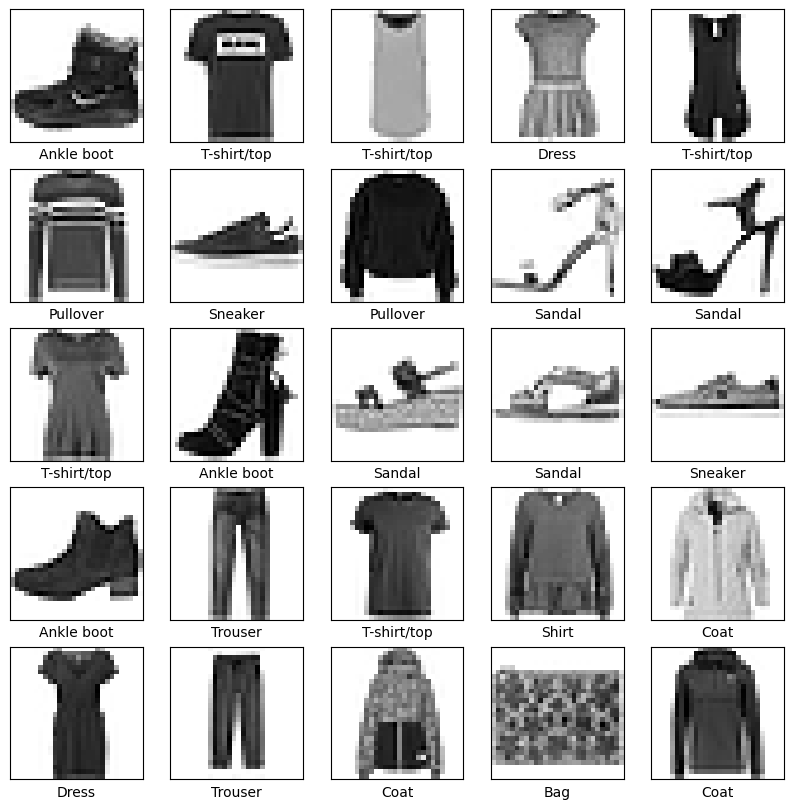

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# plot 4 images as gray scale
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [3]:
# flatten 28*28 images to a 784 vector for each image
IMG_HEIGHT=28
IMG_WIDTH= 28
channels =1 

In [4]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

# One-hot encode the labels for F1Score compatibility
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [5]:
#Create the model:
# Input layer with shape=(IMG_HEIGHT, IMG_WIDTH) as the first layer
# Flatten() layer without the deprecated input_shape parameter
loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
model = tf.keras.Sequential([
                             tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH)),
                             tf.keras.layers.Flatten(),
                             tf.keras.layers.Dense(128, activation='relu'),
                             tf.keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

In [6]:
# Train the model here
hist = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=128)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.7363 - loss: 0.7763 - val_accuracy: 0.8413 - val_loss: 0.4586
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - accuracy: 0.8531 - loss: 0.4223 - val_accuracy: 0.8577 - val_loss: 0.4085
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.8648 - loss: 0.3847 - val_accuracy: 0.8658 - val_loss: 0.3760
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8767 - loss: 0.3481 - val_accuracy: 0.8697 - val_loss: 0.3680
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.8808 - loss: 0.3281 - val_accuracy: 0.8693 - val_loss: 0.3604
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.8870 - loss: 0.3085 - val_accuracy: 0.8808 - val_loss: 0.3420
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.8884 - loss: 0.3022 - val_accuracy: 0.8822 - val_loss: 0.3331
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - accuracy: 0.8947 - loss: 0.2898 - 

In [7]:
hist.history

{'accuracy': [0.8019999861717224,
  0.851479172706604,
  0.8660833239555359,
  0.8753541707992554,
  0.8794166445732117,
  0.8863124847412109,
  0.8913750052452087,
  0.893875002861023,
  0.898187518119812,
  0.9022499918937683,
  0.9058958292007446,
  0.9068958163261414,
  0.9098958373069763,
  0.913770854473114,
  0.9164791703224182,
  0.9182291626930237,
  0.9191041588783264,
  0.9220208525657654,
  0.9238541722297668,
  0.9270416498184204],
 'loss': [0.575387179851532,
  0.42294591665267944,
  0.37881380319595337,
  0.3500470519065857,
  0.33153507113456726,
  0.31201761960983276,
  0.29920637607574463,
  0.2910017967224121,
  0.280665785074234,
  0.2676309049129486,
  0.25853243470191956,
  0.25186070799827576,
  0.24310064315795898,
  0.23519869148731232,
  0.22913862764835358,
  0.22378230094909668,
  0.2197664976119995,
  0.21371960639953613,
  0.20871354639530182,
  0.2004573792219162],
 'val_accuracy': [0.8412500023841858,
  0.8577499985694885,
  0.8658333420753479,
  0.86966

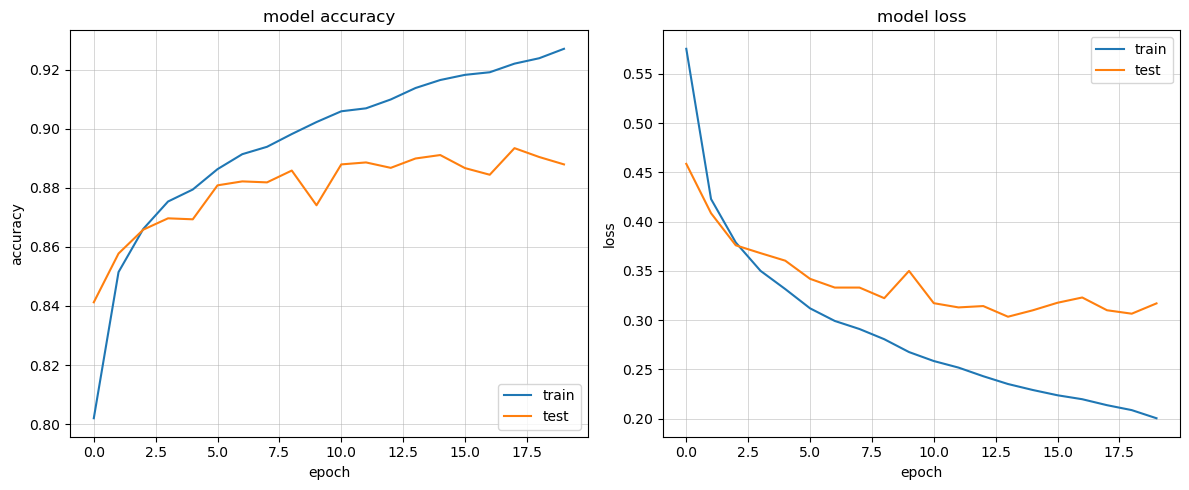

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.grid(linewidth=0.5, alpha=0.7)
plt.legend(['train', 'test'], loc='lower right')

plt.subplot(1,2,2)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.grid(linewidth=0.5, alpha=0.7)
plt.legend(['train', 'test'], loc='upper right')

plt.tight_layout()
plt.show()

# Discussion
The model is a simple feedforward neural network with one hidden layer. 
It uses the ReLU activation function in the hidden layer and softmax 
activation in the output layer for multi-class classification, in this case, 10.
The model is trained using the Adam optimizer and sparse categorical cross-entropy 
loss function, which is suitable for integer-labeled multi-class classification tasks. 
The only metric generated was accuracy. The training process includes a validation 
split to monitor the model's performance on unseen data during training. 
The accuracy and loss plots indicate how well the model learns over epochs, 
showing improvements in both metrics.

**Part 2- Image Processing**

Load the Flower photo dataset from tensorflow repository

In [9]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url,
                                   fname='flower_photos',
                                   untar=True)
data_dir = pathlib.Path(data_dir) 

*a) How many images we can find in this dataset?*




In [10]:
data_dir_sub = (data_dir / 'flower_photos').resolve()
images = list(data_dir_sub.rglob('**/*.jpg'))  #This will count all the file with extension of jpg- You have to modify this part
print(len(images))

3670


*b) The list of subfolders are:*
*   daisy
*   dandelion
*   roses
*   sunflowers
*   tulips

You can look into any of the subfolders to see images stored over there. You can look into the folder using: data_dir.glob('tulips/*')
For this part use Pillow (PIL) to show at least one flower from each subfolder


tulips images
daisy images
roses images
sunflowers images
dandelion images


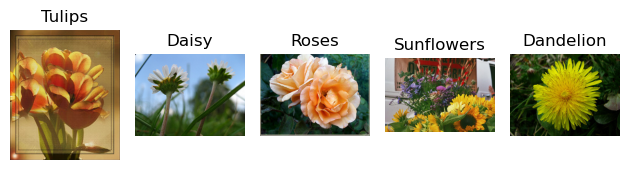

In [11]:
# There are 5 subfolders in the dataset
select_images = {'tulips': None, 'daisy': None, 'roses': None, 'sunflowers': None, 'dandelion': None}
for flower in select_images.keys():
    print(f"{flower} images")
    ddir = (data_dir_sub / flower).resolve()
    imgs = list(ddir.rglob('*.jpg'))
    if imgs:
        img_path = list(imgs)[2]
        select_images[flower] = PIL.Image.open(img_path) 
    else:
        print(f"No images found for {flower}")

for i, (flower_name, img) in enumerate(select_images.items()):
    if img:
        # Create a subplot for each image (1 row, 5 columns, current index + 1)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(flower_name.capitalize())
        plt.axis('off')

plt.tight_layout()
plt.show()

*c) Use Keras to resize all the images into same dimension 180x180*

In [12]:
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir_sub,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [13]:
# Use the same strategy to create validation data, this time from validation subset
val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir_sub,
    validation_split=0.2, 
    subset="validation",
    seed=123,
    # Resize
    image_size=(img_height, img_width), 
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


d) *You can use* `train_ds.class_names` *command to get the list of labels. Write a code to randomly show 9 images from training data while printing their label on top of the image.*

2025-10-27 19:55:17.517728: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


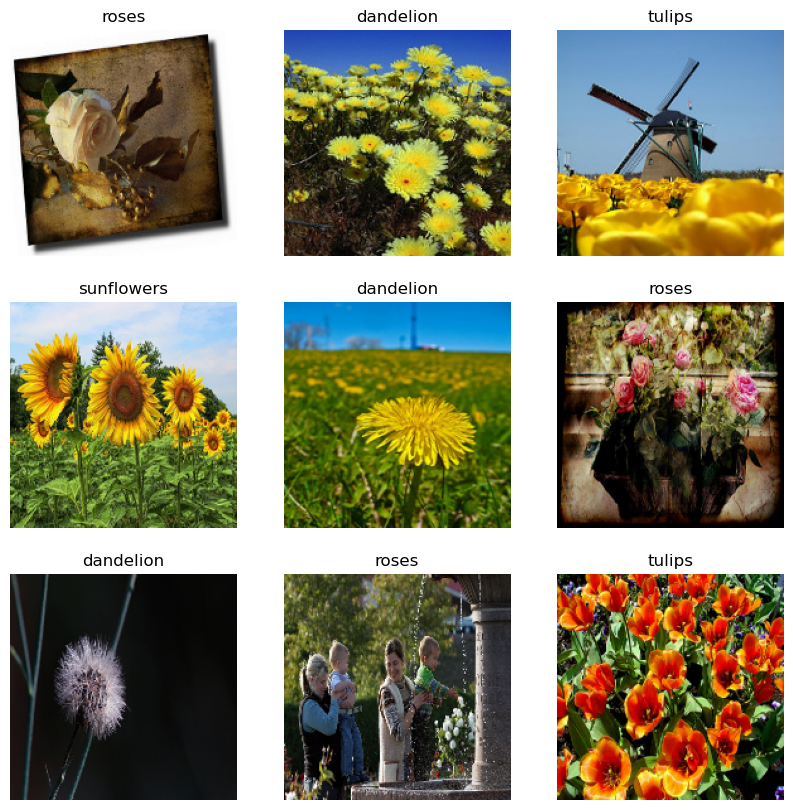

In [14]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

### Difficulties in the ML properly indentifying these images
The images are take from different perspectives: some near (close up) and some far away. This will cause a problem because some strongly identifying features are enhanced in a close up but disappear when further away. In another image the sun is low in the sky putting a dandelion in the shadows but outlining the stem of the flower inside the sphere of seeds around it. IN some cases the butterfly hides parts of the flower and in another a flower is shown in different stages of development (which look nothing alike if you are not aware of the flowers life cycle). Moreover, some images have dominate features that is not a flower and might confuse the model. Finally, some images are sharpe and some are a bit blurry. All of these issues affect the data's health, which is not uniform, which will affect the computer vision's ability to mathematically identify flowers when predicting.

*e* - *Now, we want to use preprocessing package in Keras to apply different filters to the image. Apply the following procedures to image data:*
- *Rescale the image by dividing by 255*
- *Shear the image 20%*
- *Zoom the image 20%*
- *Horizontally flip the images*

In [15]:
# Modern preprocessing pipeline (replacement for deprecated ImageDataGenerator)
# Using the modern preprocessing/augmentation pipeline we use for the flower dataset. 

AUTOTUNE = tf.data.AUTOTUNE # lets TensorFlow pick optimal parallelism/prefetching.

# Data augmentation and rescaling
data_augmentation = keras.Sequential([
    layers.Rescaling(1.0/255), # scales from 0-255 to 0-1
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.2), # zoom to about 20% 
    layers.RandomRotation(0.05),  # small rotation as a proxy for shear
])

# Apply to datasets
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y), num_parallel_calls=AUTOTUNE)

# Performance: cache and prefetch
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

**Part 3- OPENCV**- Now use opencv for preprocessing. Show first 9 images in dataset using Opencv. Before showing each image, resize the images to 180x180.

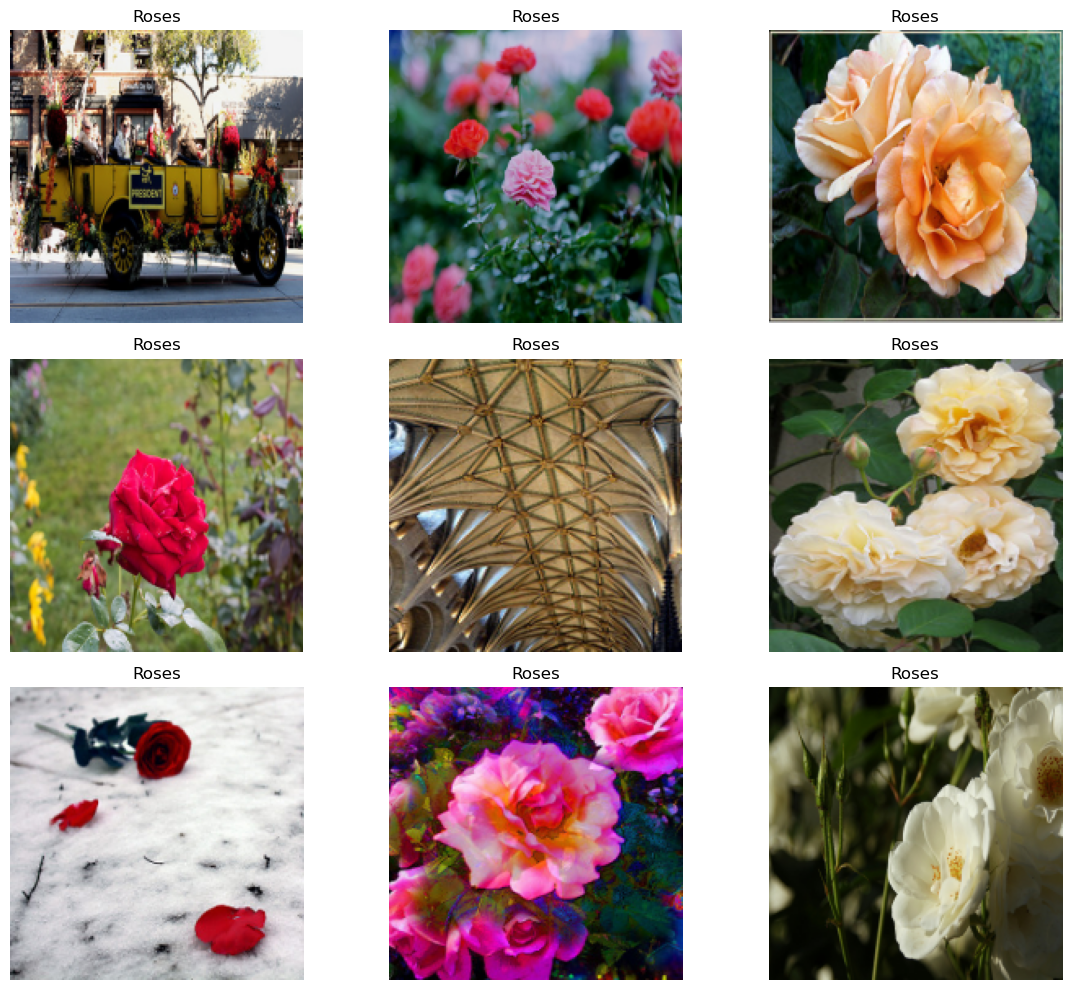

In [16]:
# Repeat same preprocessing but this time using OpenCV. Show first 9 images in dataset using OpenCV.

# Collect images from the flower_photos subdirectory
list_of_images = list((data_dir / 'flower_photos').glob('*/*.jpg'))

plt.figure(figsize=(12, 10))
for i in range(9):
    img_path = Path(list_of_images[i])
    img = cv2.imread(str(img_path))  # BGR format
    if img is None:
        continue
    # Resize to 180x180 and convert to RGB for matplotlib
    img_resized = cv2.resize(img, (180, 180), interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(img_path.parent.name.capitalize())
    plt.axis('off')

plt.tight_layout()
plt.show()

OpenCV uses BGR as its default colour order for images, matplotlib uses RGB. When you display an image loaded with OpenCv in matplotlib the channels will be back to front.
The easiest way of fixing this is to use OpenCV to explicitly convert it back to RGB, much like you do when creating the greyscale image.
`RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`

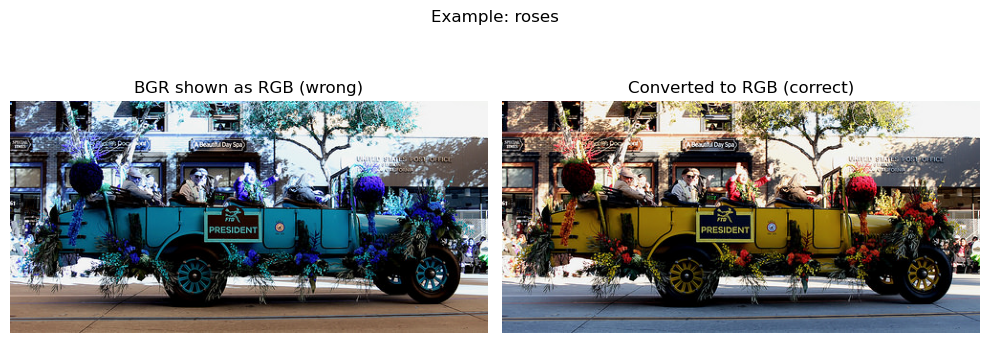

In [17]:
# Demonstrate BGR vs RGB display and the proper conversion

# Pick one sample image
candidates = list((data_dir / 'flower_photos').glob('*/*.jpg'))
if not candidates:
    raise RuntimeError("No images found under flower_photos. Run the download/setup cells above.")

img_path = Path(candidates[0])
img_bgr = cv2.imread(str(img_path))  # OpenCV reads in BGR
if img_bgr is None:
    raise RuntimeError(f"Failed to read image: {img_path}")

# Wrong display (treating BGR as RGB) vs Correct display (after conversion)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_bgr)  # Incorrect colors because it's BGR interpreted as RGB
plt.title("BGR shown as RGB (wrong)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title("Converted to RGB (correct)")
plt.axis("off")

plt.suptitle(f"Example: {img_path.parent.name}")
plt.tight_layout()
plt.show()